# plot points

In [154]:

from matplotlib.pylab import eigvals
import torch
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from scipy.spatial import cKDTree, distance
from scipy.linalg import solve, lstsq,lu_factor, lu_solve
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve, splu
import matplotlib.pyplot as plt
from math import pi
from scipy.stats import qmc

dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
# =========================================================
# 1. 2D star-shaped boundary
# =========================================================
def r_max_func(theta):
    return 2.0 * (0.7 + 0.12 * (np.sin(6 * theta) + np.sin(3 * theta)))


# =========================================================
# 2. inside test
# =========================================================
def inside_star_2d(x, y, eps=1e-12):
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    theta = np.where(theta < 0, theta + 2 * np.pi, theta)
    return r <= r_max_func(theta) + eps


# =========================================================
# 3. unique points
# =========================================================
def unique_points_by_tol(X, tol=1e-10):
    X = np.asarray(X, dtype=np.float64)
    Xq = np.round(X / tol).astype(np.int64)
    _, idx = np.unique(Xq, axis=0, return_index=True)
    idx = np.sort(idx)
    return X[idx]


# =========================================================
# 4. generate boundary points
# =========================================================
def generate_boundary_points_2d(N_boundary=1000):
    theta = np.linspace(0.0, 2 * np.pi, N_boundary, endpoint=False)
    r = r_max_func(theta)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    return np.vstack([x, y]).T


# =========================================================
# 5. generate patch centers and H
# =========================================================
def generate_centers_auto_H_2d(N_patch_grid, margin=0.1):
    """
    Generate Cartesian patch centers from the bounding box of the 2D star domain.

    Returns
    -------
    C : ndarray, shape (N_patch_grid^2, 2)
        Raw patch centers.

    H : float
        max(Hx, Hy).
    """
    theta = np.linspace(0.0, 2 * np.pi, 4000, endpoint=False)
    r = r_max_func(theta)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    # 这里 margin 和你 3D 代码一致，是绝对外扩量，不是比例
    x_min = x.min() - margin
    x_max = x.max() + margin
    y_min = y.min() - margin
    y_max = y.max() + margin

    Hx = (x_max - x_min) / (N_patch_grid - 1)
    Hy = (y_max - y_min) / (N_patch_grid - 1)
    H = max(Hx, Hy)

    Cx = np.linspace(x_min, x_max, N_patch_grid)
    Cy = np.linspace(y_min, y_max, N_patch_grid)

    Xg, Yg = np.meshgrid(Cx, Cy, indexing="ij")
    C = np.vstack([Xg.ravel(), Yg.ravel()]).T

    return C, H


def compute_R_from_H_delta_2d(H, delta):
    """
    In 2D, a square cell of spacing H is covered by a disk radius sqrt(2)*H/2.
    Add overlap factor delta:

        R = (1 + delta) * sqrt(2) * H / 2.
    """
    return (1.0 + delta) * np.sqrt(2.0) * H / 2.0


# =========================================================
# 6. generate inner points via patch disks + filter to domain
# =========================================================
def generate_inner_points_2d(C, R, N_local):
    """
    For each patch center c, generate N_local Halton points uniformly in disk B(c,R),
    then keep only points inside the star-shaped domain.
    """
    X_list = []

    for c in C:
        sampler = qmc.Halton(d=2, scramble=False)
        pts = sampler.random(N_local)

        u = pts[:, 0]
        v = pts[:, 1]

        theta = 2 * np.pi * u
        rr = R * np.sqrt(v)

        x = c[0] + rr * np.cos(theta)
        y = c[1] + rr * np.sin(theta)

        X_list.append(np.vstack([x, y]).T)

    X_raw = np.vstack(X_list)

    mask = inside_star_2d(X_raw[:, 0], X_raw[:, 1])
    X_inner = X_raw[mask]

    return X_inner


# =========================================================
# 7. remove empty patches
# =========================================================
def remove_empty_patches_by_Xinner_2d(C_raw, R, X_inner):
    """
    Remove patches that contain no interior points.

    Parameters
    ----------
    C_raw : ndarray, shape (Np,2)
    R : scalar or ndarray
    X_inner : ndarray, shape (N,2)

    Returns
    -------
    C_new : ndarray, shape (Np_new,2)
    R_new : ndarray, shape (Np_new,)
    keep : ndarray, bool
    nX : ndarray, shape (Np,)
    """
    C_raw = np.asarray(C_raw, dtype=np.float64)
    X_inner = np.asarray(X_inner, dtype=np.float64)

    if np.isscalar(R):
        R_vec = np.full(C_raw.shape[0], R, dtype=np.float64)
    else:
        R_vec = np.asarray(R, dtype=np.float64)

    tree_X = cKDTree(X_inner)

    keep = np.zeros(C_raw.shape[0], dtype=bool)
    nX = np.zeros(C_raw.shape[0], dtype=int)

    for j, c in enumerate(C_raw):
        idx = tree_X.query_ball_point(c, R_vec[j])
        nX[j] = len(idx)
        keep[j] = nX[j] > 0

    C_new = C_raw[keep]
    R_new = R_vec[keep]

    print(f"original patches: {C_raw.shape[0]}")
    print(f"kept patches: {C_new.shape[0]}")
    print(f"removed patches: {C_raw.shape[0] - C_new.shape[0]}")

    if np.any(keep):
        print(
            "patch nX min/mean/max: "
            f"{nX[keep].min()} / {nX[keep].mean():.2f} / {nX[keep].max()}"
        )
    else:
        print("No patches kept!")

    return C_new, R_new, keep, nX


# =========================================================
# 8. fill distance
# =========================================================
def fill_distance(nodes):
    nodes = np.asarray(nodes, dtype=np.float64)

    if nodes.shape[0] <= 1:
        return 0.0

    tree = cKDTree(nodes)
    dists, _ = tree.query(nodes, k=2, workers=-1)

    return np.float64(np.max(dists[:, 1]))


# =========================================================
# 9. coverage diagnostics
# =========================================================
def patch_cover_stats_2d(C, R, X):
    """
    Count how many patches cover each point in X.
    """
    C = np.asarray(C, dtype=np.float64)
    X = np.asarray(X, dtype=np.float64)

    if np.isscalar(R):
        R_vec = np.full(C.shape[0], R, dtype=np.float64)
    else:
        R_vec = np.asarray(R, dtype=np.float64)

    cover = np.zeros(X.shape[0], dtype=int)

    for j, c in enumerate(C):
        tree = cKDTree(X)
        idx = tree.query_ball_point(c, R_vec[j])
        cover[idx] += 1

    return {
        "cover_min": int(cover.min()),
        "cover_mean": float(cover.mean()),
        "cover_max": int(cover.max()),
        "uncovered": int(np.sum(cover == 0)),
        "cover": cover,
    }


# =========================================================
# 10. visualization
# =========================================================
def visualize_points_2d(X_inner, X_boundary, C=None, R=None):
    theta = np.linspace(0.0, 2 * np.pi, 1000, endpoint=False)
    rb = r_max_func(theta)

    xb = rb * np.cos(theta)
    yb = rb * np.sin(theta)

    plt.figure(figsize=(7, 7))
    ax = plt.gca()

    ax.plot(xb, yb, "k-", linewidth=1.0, label="Boundary curve")

    if C is not None and R is not None:
        R_vec = R if not np.isscalar(R) else np.full(len(C), R)
        th = np.linspace(0, 2 * np.pi, 200)
        for j, c in enumerate(C):
            ax.plot(
                c[0] + R_vec[j] * np.cos(th),
                c[1] + R_vec[j] * np.sin(th),
                "k:",
                linewidth=0.6,
                alpha=0.5,
            )
        ax.scatter(C[:, 0], C[:, 1], s=20, marker="x", color="green", label="Patch centers")

    if X_inner.shape[0] > 0:
        ax.scatter(
            X_inner[:, 0],
            X_inner[:, 1],
            s=8,
            color="red",
            alpha=0.7,
            label="Interior points",
        )

    if X_boundary.shape[0] > 0:
        ax.scatter(
            X_boundary[:, 0],
            X_boundary[:, 1],
            s=10,
            color="blue",
            alpha=0.8,
            label="Boundary points",
        )

    ax.set_aspect("equal", "box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, linewidth=0.4, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 11. main generator
# =========================================================
def generator_points_2d_overlap(
    N_patch_grid,
    N_local_per_patch,
    N_boundary,
    overlap,
    visu=True,
):
    """
    2D overlap version following your 3D generation logic.

    Parameters
    ----------
    N_patch_grid : int
        Number of patch centers per dimension.

    N_local_per_patch : int
        Number of Halton samples generated in each raw patch disk.

    N_boundary : int
        Number of boundary points.

    overlap : float
        Same role as delta in 3D:
            R = (1+overlap)*sqrt(2)*H/2.

    visu : bool
        Whether to visualize.

    Returns
    -------
    X_inner : ndarray, shape (N_inner,2)
    X_boundary : ndarray, shape (N_boundary,2)
    C : ndarray, shape (Np,2)
    R : ndarray, shape (Np,)
    info : dict
    """

    X_boundary = generate_boundary_points_2d(N_boundary)
    X_boundary = unique_points_by_tol(X_boundary, tol=1e-10)

    # 1. raw centers
    C_raw, H = generate_centers_auto_H_2d(N_patch_grid, margin=0.1)

    # 2D local fill-distance estimate
    h = H / np.sqrt(N_local_per_patch)

    info = {
        "H": H,
        "h": h,
    }

    print("Generator's raw C:", len(C_raw))

    # 2. compute R from overlap
    R_scalar = compute_R_from_H_delta_2d(H, overlap)
    print("Generator's R =", R_scalar)

    # 3. generate inner points and filter centers
    X_inner = generate_inner_points_2d(C_raw, R_scalar, N_local_per_patch)
    X_inner = unique_points_by_tol(X_inner, tol=1e-10)

    C, R, _, _ = remove_empty_patches_by_Xinner_2d(C_raw, R_scalar, X_inner)

    print("X_inner:", len(X_inner))
    print("X_boundary:", len(X_boundary))

    # 4. coverage stats for X_inner and all X
    stat_inner = patch_cover_stats_2d(C, R, X_inner)
    X_all = np.vstack([X_inner, X_boundary])
    stat_all = patch_cover_stats_2d(C, R, X_all)

    print(
        "cover X_inner min/mean/max:",
        stat_inner["cover_min"],
        f"{stat_inner['cover_mean']:.2f}",
        stat_inner["cover_max"],
        "uncovered:",
        stat_inner["uncovered"],
    )

    print(
        "cover X_all min/mean/max:",
        stat_all["cover_min"],
        f"{stat_all['cover_mean']:.2f}",
        stat_all["cover_max"],
        "uncovered:",
        stat_all["uncovered"],
    )

    info.update({
        "R": R_scalar,
        "num_raw_patches": len(C_raw),
        "num_patches": len(C),
        "N_inner": len(X_inner),
        "N_boundary": len(X_boundary),
        "cover_inner_min": stat_inner["cover_min"],
        "cover_inner_mean": stat_inner["cover_mean"],
        "cover_inner_max": stat_inner["cover_max"],
        "cover_inner_uncovered": stat_inner["uncovered"],
        "cover_all_min": stat_all["cover_min"],
        "cover_all_mean": stat_all["cover_mean"],
        "cover_all_max": stat_all["cover_max"],
        "cover_all_uncovered": stat_all["uncovered"],
    })
    # 5. visualization
    if visu:
        visualize_points_2d(X_inner, X_boundary, C=C, R=R)
    return X_inner, X_boundary, C, R, info


def laplacian_phi_wrt_y(phi_net, y, X):
    """
    Compute phi, physical gradient, and physical Laplacian
    for multi-output local radial/Fourier-like features.
    Input:
        y : (M, 2)
        X : (K, 2)
    phi_net receives r with shape (M, K, 1), and returns one of:
        (M, K*out_d)
        (M, K*out_d, 1)
        (M, K, out_d)
    Output:
        phi_vals : (M, K*out_d)
        lap_y    : (M, K*out_d)
        grad_y   : (M, K*out_d, 2)
    """
    y = torch.as_tensor(y, dtype=torch.float64, device=device)
    X = torch.as_tensor(X, dtype=torch.float64, device=device)

    if y.dim() == 1:
        y = y.unsqueeze(0)
    if X.dim() == 1:
        X = X.unsqueeze(0)

    M = y.shape[0]
    K = X.shape[0]
    dim = y.shape[1]
    # --------------------------------------------------
    # Pairwise difference in scaled coordinates
    # diff_hat = y_hat - X_hat
    # --------------------------------------------------
    diff = y[:, None, :] - X[None, :, :]          # (M,K,dim)
    r0 = torch.norm(diff, dim=2, keepdim=True)    # (M,K,1)
    r0 = r0.clamp(min=1e-12)
    # Treat r as independent variable for radial derivative
    r = r0.clone().detach().requires_grad_(True)
    # --------------------------------------------------
    # phi(r_hat)
    # Expected final shape: (M, K, out_d)
    # --------------------------------------------------
    phi_raw = phi_net(r)
    if phi_raw.dim() == 3 and phi_raw.shape[-1] == 1:
        # e.g. (M, K*out_d, 1)
        phi_raw = phi_raw.squeeze(-1)

    if phi_raw.dim() == 2:
        # e.g. (M, K*out_d)
        assert phi_raw.shape[0] == M
        assert phi_raw.shape[1] % K == 0
        out_d = phi_raw.shape[1] // K
        phi = phi_raw.view(M, K, out_d)           # (M, K, out_d)

    elif phi_raw.dim() == 3:
        # e.g. (M, K, out_d)
        assert phi_raw.shape[0] == M
        assert phi_raw.shape[1] == K
        out_d = phi_raw.shape[2]
        phi = phi_raw                              # (M, K, out_d)

    else:
        raise ValueError(f"Unexpected phi_net output shape: {phi_raw.shape}")
    # --------------------------------------------------
    # Compute dphi/dr and d2phi/dr2 for each output channel
    # Important: do NOT sum all output channels together.
    # --------------------------------------------------
    phi_cpu = np.empty((M, K * out_d), dtype=np.float64)
    lap_cpu = np.empty((M, K * out_d), dtype=np.float64)
    grad_cpu = np.empty((M, K * out_d, dim), dtype=np.float64)
    r2 = r.squeeze(-1)                            # (M,K)
    for q in range(out_d):
        phi_q = phi[:, :, q:q+1]                  # (M,K,1)
        dphi_q = torch.autograd.grad(
            outputs=phi_q,
            inputs=r,
            grad_outputs=torch.ones_like(phi_q),
            create_graph=True,
            retain_graph=True
        )[0]                                      # (M,K,1)
        d2phi_q = torch.autograd.grad(
            outputs=dphi_q,
            inputs=r,
            grad_outputs=torch.ones_like(dphi_q),
            create_graph=False,
            retain_graph=True
        )[0]                                      # (M,K,1)
        lap_hat_q = d2phi_q + (dim - 1) * dphi_q / r2[:, :, None]
        grad_hat_q = (
            dphi_q[:, :, :, None]
            * diff[:, :, None, :]
            / r2[:, :, None, None]
        )                                        # (M,K,1,dim)
        lap_q = lap_hat_q                        # (M,K,1)
        grad_q = grad_hat_q                      # (M,K,1,dim)
        col0 = q
        cols = np.arange(q, K * out_d, out_d)
        # phi.reshape(M,K*out_d) 默认是 [k0_q0,k0_q1,...,k1_q0,k1_q1,...]
        phi_cpu[:, cols] = phi_q.squeeze(-1).detach().cpu().numpy()
        lap_cpu[:, cols] = lap_q.squeeze(-1).detach().cpu().numpy()
        grad_cpu[:, cols, :] = grad_q.squeeze(2).detach().cpu().numpy()
        del phi_q, dphi_q, d2phi_q, lap_hat_q, grad_hat_q, lap_q, grad_q
    del phi_raw, phi, r, r0, r2, diff, y, X
    return phi_cpu, lap_cpu, grad_cpu

def rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    t: [0:tau:T] tau: step length
    f_func, g_func, u_0func: Python callable returning torch tensor
    K: number of neighbors
    order: 0
    """
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]
    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    LBDF2 = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))
    W_ide = np.zeros((M, K))
    W_lap = np.zeros((M, K))
    # Construct RHS
    RHS = np.zeros((M,1))
    if callable(f_func):
        f_val = f_func(Yin[:,0:1], Yin[:,1:2],t)
    elif isinstance(f_func, np.ndarray):
        f_val = f_func # (M1,NT)
    else:
        raise ValueError("f_func must be callable or numpy array")
    if callable(g_func):
        g_val = g_func(Yb[:,0:1], Yb[:,1:2],t)
    elif isinstance(g_func, np.ndarray):
        g_val = g_func # (M2,NT)
    else:
        raise ValueError("g_func must be callable or numpy array")
    if callable(u0_func):
        u0 = u0_func(Y[:,0:1], Y[:,1:2])
    elif isinstance(u0_func, np.ndarray):
        u0 = u0_func[:,None] # (M,1)
    else:
        raise ValueError("u0_func must be callable or numpy array")

    for i in range(M):
        RHS_lap = np.zeros((K,1))
        RHS_ide = np.ones((K,1))
        A = np.zeros((K,K))
        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ).reshape(K, -1) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        # print(np.max(np.max(Phi_jj)), np.min(np.min(Phi_jj)))
        phi_xj, lap_phi, _  = laplacian_phi_wrt_y(Phi, y, Z) # (1,K)
        ## RHS_lap, RHS_ide
        RHS_lap = lap_phi.T
        RHS_ide = phi_xj.T
        ## W_ide, W_lap
        A  =  Phi_jj  + reg * np.eye(K) # (K,K)
        w_ide = np.linalg.solve(A,RHS_ide).T
        W_ide[i,:] = w_ide
        w_lap = np.linalg.solve(A,RHS_lap).T
        W_lap[i,:] = w_lap
        if i < M1 :
            LBDF1[i,idx_local] += (w_ide - tau * w_lap)
            LBDF2[i,idx_local] += (3 * w_ide - 2* tau * w_lap)
        else:
            LBDF1[i,idx_local] += w_ide
            LBDF2[i,idx_local] += w_ide
        LI[i,idx_local] += w_ide
    
    U = lil_matrix((M, NT))
    U[:,0:1] = u0   # (N,1)
    U[M1:,:] = g_val

    LI = LI.tocsr()
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()
    cond_LI = np.linalg.cond(LI.todense())
    print("cond(LI) =", cond_LI)
    cond_LBDF1 = np.linalg.cond(LBDF1.todense())
    print("cond(LBDF1) =", cond_LBDF1)
    cond_LBDF2 = np.linalg.cond(LBDF2.todense())
    print("cond(LBDF2) =", cond_LBDF2)

    if M == N:
        # BDF1
        alpha_0 = spsolve(LI,u0)[:,None]
        right1 = LI @ alpha_0             # (M,1)
        rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
        alpha_1 = spsolve(LBDF1,RHS)[:,None]
        U[:,1:2] = LI @ alpha_1
        # U[:M1,1:2] = LI[:M1, :] @ alpha_1
        # U[M1:,1:2]  = g_val[:,1:2]
        # BDF2
        LU = splu(LBDF2.tocsc())
        for i in range(1,NT-1):  # NT-2
            right1 = LI @ (4 * alpha_1 - alpha_0)
            rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
            RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
            # alpha_2 = spsolve(LBDF2,RHS)[:,None]
            alpha_2 = LU.solve(RHS)
            U[:,i+1:i+2] = LI @ alpha_2
            alpha_0 = alpha_1
            alpha_1 = alpha_2

    else:
        print("M $\neq$ N. Please use QR.")

        # Q, R = np.linalg.qr(L1.toarray(), mode='reduced')
        # UX = np.linalg.solve(R, Q.T @ RHS)
    return U,LBDF1,LBDF2,LI

def poly2D(Z, order):
    K = Z.shape[0]
    Norder = (order+1)*(order+2)//2
    P = np.zeros((K, Norder))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            P[:, idx] = (Z[:,0]**i) * (Z[:,1]**j)
            idx += 1
    return P

def poly2D_at_point(y, order):
    """Generate column vector of poly basis at single point y (2D)"""
    Norder = (order+1)*(order+2)//2
    p_y = np.zeros((Norder,1))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            p_y[idx,0] = (y[0]**i) * (y[1]**j)
            idx += 1
    return p_y

def laplacian_poly2D(order, y):
    """
    y: (2,) point
    return: column vector (Norder,1) of Laplacian evaluated at y
    """
    Norder = (order+1)*(order+2)//2
    lap = np.zeros((Norder,1))
    idx = 0
    for i in range(order+1):
        for j in range(order+1-i):
            val = 0.0
            if i >= 2:
                val += i*(i-1)*y[0]**(i-2) * y[1]**j
            if j >= 2:
                val += j*(j-1)*y[0]**i * y[1]**(j-2)
            lap[idx,0] = val
            idx += 1
    return lap

def rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: polynomial order (1,2,3,...)
    """
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]

    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    LBDF2 = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))

    # Construct RHS
    RHS = np.zeros((M,1))
    f_val = f_func(Yin[:,0:1], Yin[:,1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:,0:1], Yb[:,1:2], t) if callable(g_func) else g_func
    u0 = u0_func(Y[:,0:1], Y[:,1:2]) if callable(u0_func) else u0_func[:, None]

    O = np.zeros((Norder,Norder))
    for i in range(M):
        RHS_lap = np.zeros((K+Norder,1))
        RHS_ide = np.ones((K+Norder,1))
        AP = np.zeros((K+Norder,K+Norder))
        P = np.ones((K,Norder))
        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)

        c = np.mean(Z, axis=0, keepdims=True)
        r = np.max(np.linalg.norm(Z - c, axis=1))
        Z = (Z - c) / r
        y = ((y[None, :] - c) / r).reshape(2,)

        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ).reshape(K,-1) # (K,K * n_out)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        Phi_reg = Phi_jj @ Phi_jj.T 
        phi_xj, lap_phi, _  = laplacian_phi_wrt_y(Phi, y, Z) # (1,K*n_out)
        lap_phi = lap_phi/r**2
        P = poly2D(Z, order)  # (K,Norder)
        AP[:K,:] = np.concatenate([Phi_reg,P], axis = 1) # (K,K+3)
        AP[K:,:-Norder] = P.T # (Norder,K)
        AP = AP + reg * np.eye(K+Norder)
        LU = lu_factor(AP)
        ## w_ide, w_lap
        p_y = poly2D_at_point(y, order)  # (Norder,1)
        RHS_ide[:K,0:1] = Phi_jj @ (phi_xj.T)                       # shape (K,)
        RHS_ide[K:,0:1] = p_y[:,0:1]
        w_ide = lu_solve(LU, RHS_ide).T # (1,K+Norder)
        RHS_lap[:K,0:1] = Phi_jj @ (lap_phi.T)
        RHS_lap[K:,0:1] = laplacian_poly2D(order, y)[:,0:1]/r**2
        w_lap = lu_solve(LU, RHS_lap).T # (1,K+Noder)

        if i < M1 :
            LBDF1[i:i+1,idx_local] += (w_ide[0:1,:K] - tau * w_lap[0:1,:K])
            LBDF2[i:i+1,idx_local] += (3 * w_ide[0:1,:K] - 2* tau * w_lap[0:1,:K])
        else:
            LBDF1[i:i+1,idx_local] += w_ide[0:1,:K]
            LBDF2[i:i+1,idx_local] += w_ide[0:1,:K]
        LI[i:i+1,idx_local] += w_ide[0:1,:K]
        
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    U = lil_matrix((M, NT))
    U[:,0:1] = u0   # (N,1)
    U[M1:,:] = g_val

    LI = LI.tocsr()
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()
    cond_LI = np.linalg.cond(LI.todense())
    print("cond(LI) =", cond_LI)
    cond_LBDF1 = np.linalg.cond(LBDF1.todense())
    print("cond(LBDF1) =", cond_LBDF1)
    cond_LBDF2 = np.linalg.cond(LBDF2.todense())
    print("cond(LBDF2) =", cond_LBDF2)


    if M == N:
        # BDF1
        alpha_0 = spsolve(LI,u0)[:,None]
        right1 = LI @ alpha_0             # (M,1)
        rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
        alpha_1 = spsolve(LBDF1,RHS)[:,None]
        U[:M1,1:2] = LI[:M1, :] @ alpha_1
        U[M1:,1:2]  = g_val[:,1:2]
        # BDF2
        LU = splu(LBDF2.tocsc())
        for i in range(1,NT-1):  # NT-2
            right1 = LI @ (4 * alpha_1 - alpha_0)
            rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
            RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
            alpha_2 = LU.solve(RHS)
            U[:M1,i+1:i+2] = LI[:M1, :] @ alpha_2
            U[M1:,i+1:i+2] = g_val[:,i+1:i+2]
            alpha_0 = alpha_1
            alpha_1 = alpha_2
    else:
        print("M $\neq$ N. Please use QR.")
        
    return U,LBDF1,LBDF2,LI


def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))

In [155]:

class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(6.2)**2 * x**2)
        # output = torch.exp(-(0.9225)**2 * x**2) # operator
        output = self.input_layer(x)
        output = torch.sigmoid(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.uniform_(m.bias, -np.pi, np.pi)



class PhiNet1(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet1, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = False)

    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        output = torch.cos(self.input_layer(x))
        output = torch.sin(self.output_layer(output))
        if output.shape[0] != K: 
            output = output.view(K, -1)
        return output

    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                # nn.init.uniform_(m.weight, a = -1, b = 1)
                if m.bias is not None:
                    nn.init.uniform_(m.bias, -torch.pi, torch.pi)
                    #  nn.init.uniform_(m.bias, -1, 1)

Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 20
removed patches: 5
patch nX min/mean/max: 15 / 222.05 / 498
X_inner: 1759
X_boundary: 200
cover X_inner min/mean/max: 1 2.52 4 uncovered: 0
cover X_all min/mean/max: 1 2.49 4 uncovered: 0
cond(LI) = 1.0006890584283727
cond(LBDF1) = 1832926183746132.2
cond(LBDF2) = 3665852248991768.0
(1959, 201) (1959, 201)
p = 3; L infity error in u_rfmfd: 3.350e-02
p = 3; Relative L2 error in u_rfmfd: 9.121e-03


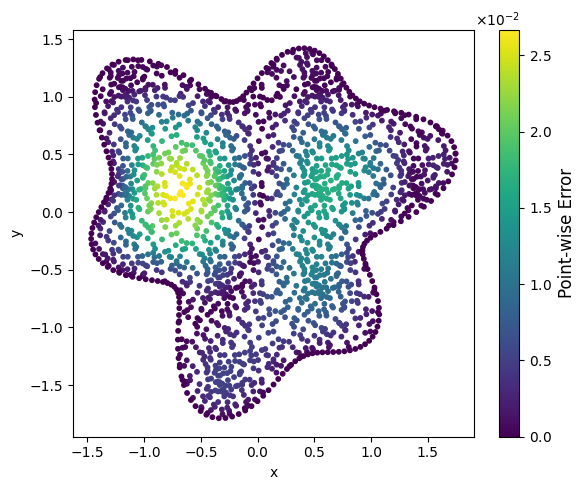

In [151]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 10
out_n = 1
Phi = PhiNet(1, hidden_size, out_n).to(device) #
Phi.initi()
Phi = Phi.double()


# # ===========================================================
u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
f_func = lambda x, y, t: np.sin(x) * np.cos(y) * np.exp(-t)
g_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
u0_func = lambda x, y : 1 + np.sin(x) * np.cos(y)

torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 200
N_boundary = 200
overlap = 0.2
# generate points
X_inner, X_boundary, _, _ , _ = generator_points_2d_overlap(
N_patch_grid, N_local_per_patch, N_boundary, overlap,False)
X = np.vstack([X_inner, X_boundary])
Yin = X_inner
Yb = X_boundary
Y = np.vstack([Yin, Yb])
M1 = Yin.shape[0]

#####
tau = 1e-3
T = 0.2 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

order = 3

K = 150
reg = 1e-13
u_true = u_func(Y[:,0:1], Y[:,1:2],t)

# # ===========================================================
if order == 0:
    U,LBDF1,LBDF2,LI = rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg)
else:
    U,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)
print(u_true.shape,U.shape)
# error = np.abs(U[M1:,:] - u_true[M1:,:])
# print(f' L infity error on bc: {error.max().item():.3e}')

error = np.abs(U - u_true)#/np.abs(u_true + 1e-6)
# print(error)
print(f'p = {order}; L infity error in u_rfmfd: {error.max().item():.3e}')
error_u = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
print(f'p = {order}; Relative L2 error in u_rfmfd: {error_u.item():.3e}')

UT = U[:,-1:].toarray().ravel()
u_true_T = u_true[:,-1:].squeeze(-1)

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UT - u_true_T), cmap='viridis', s=10)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/heat_rfmfd_p={order}_200_error.eps', bbox_inches='tight')
plt.show()


# 画收敛阶段图

Run Q=1, N_local_per_patch=15
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 19
removed patches: 6
patch nX min/mean/max: 4 / 17.58 / 38
X_inner: 128
X_boundary: 15
cover X_inner min/mean/max: 1 2.61 4 uncovered: 0
cover X_all min/mean/max: 1 2.55 4 uncovered: 0
X.shape 143
cond(LI) = 1.0000000012124852
cond(LBDF1) = 185565384725.89618
cond(LBDF2) = 371130768504.3175
h = 4.219e-01, L2 error = 7.226e-02, 
Run Q=2, N_local_per_patch=30
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 20
removed patches: 5
patch nX min/mean/max: 2 / 33.85 / 75
X_inner: 263
X_boundary: 30
cover X_inner min/mean/max: 1 2.57 4 uncovered: 0
cover X_all min/mean/max: 1 2.54 4 uncovered: 0
X.shape 293
cond(LI) = 1.0000000015410158
cond(LBDF1) = 244029313078.85898
cond(LBDF2) = 488058623504.0703
h = 2.476e-01, L2 error = 5.978e-02, 
Run Q=3, N_local_per_patch=70
Generator's raw C: 25
Generator's R = 0.7244402670709812
origina

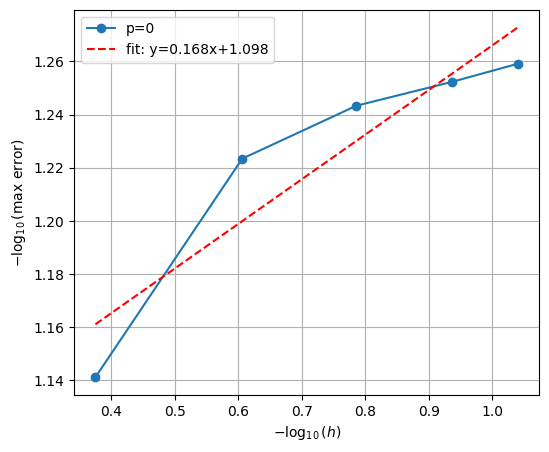

In [156]:
key = 100
np.random.seed(key)

NN = [15,30,70,100,145]
H = np.zeros((5,len(NN)))
E = np.zeros((5,len(NN)))
KK = [20,30,45,60,90]
tau = 1e-3
T = 0.2 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

RR = [1e-12,1e-12,1e-12,1e-12,1e-12]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    overlap = 0.2
    # generate points
    X_inner, X_boundary, C, R ,_ = generator_points_2d_overlap(
    N_patch_grid, N_local_per_patch, N_boundary, overlap, False)
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 0
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    K = KK[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    if order == 0:
        UY,LBDF1,LBDF2,LI = rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg)
    else:
        UY,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)
    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 19
removed patches: 6
patch nX min/mean/max: 4 / 17.58 / 38
X_inner: 128
X_boundary: 15
cover X_inner min/mean/max: 1 2.61 4 uncovered: 0
cover X_all min/mean/max: 1 2.55 4 uncovered: 0
X.shape 143
cond(LI) = 1.0000012974443075
cond(LBDF1) = 456255680014.46625
cond(LBDF2) = 912511352761.8577
h = 4.219e-01, L2 error = 4.851e-02, 
Run Q=2, N_local_per_patch=30
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 20
removed patches: 5
patch nX min/mean/max: 2 / 33.85 / 75
X_inner: 263
X_boundary: 30
cover X_inner min/mean/max: 1 2.57 4 uncovered: 0
cover X_all min/mean/max: 1 2.54 4 uncovered: 0
X.shape 293
cond(LI) = 1.0000011965465807
cond(LBDF1) = 619929121607.5474
cond(LBDF2) = 1239858229847.7065
h = 2.476e-01, L2 error = 3.434e-02, 
Run Q=3, N_local_per_patch=65
Generator's raw C: 25
Generator's R = 0.7244402670709812
origina

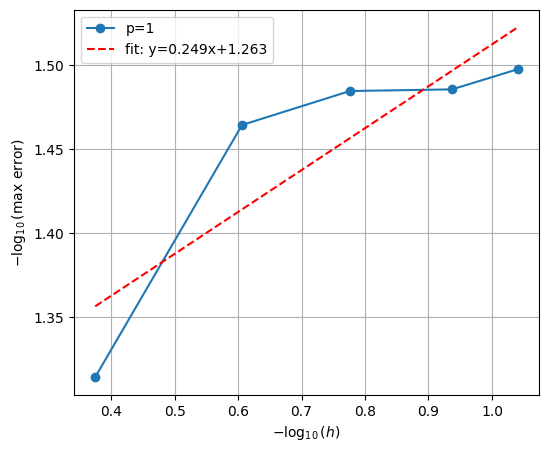

In [157]:

key = 100
np.random.seed(key)


NN = [15,30, 65, 100,145]
KK = [30,40, 50, 70, 110]
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    overlap = 0.2
    # generate points
    X_inner, X_boundary, C, R ,_ = generator_points_2d_overlap(
    N_patch_grid, N_local_per_patch, N_boundary, overlap, False)
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 1
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    K = KK[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    if order == 0:
        UY,LBDF1,LBDF2,LI = rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg)
    else:
        UY,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)
    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 19
removed patches: 6
patch nX min/mean/max: 4 / 17.58 / 38
X_inner: 128
X_boundary: 15
cover X_inner min/mean/max: 1 2.61 4 uncovered: 0
cover X_all min/mean/max: 1 2.55 4 uncovered: 0
X.shape 143
cond(LI) = 1.0000012875607416
cond(LBDF1) = 541854630023.14124
cond(LBDF2) = 1083709251177.3751
h = 4.219e-01, L2 error = 2.834e-02, 
Run Q=2, N_local_per_patch=30
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 20
removed patches: 5
patch nX min/mean/max: 2 / 33.85 / 75
X_inner: 263
X_boundary: 30
cover X_inner min/mean/max: 1 2.57 4 uncovered: 0
cover X_all min/mean/max: 1 2.54 4 uncovered: 0
X.shape 293
cond(LI) = 1.0000011666800528
cond(LBDF1) = 787227100781.4794
cond(LBDF2) = 1574454183386.0874
h = 2.476e-01, L2 error = 1.676e-02, 
Run Q=3, N_local_per_patch=65
Generator's raw C: 25
Generator's R = 0.7244402670709812
origin

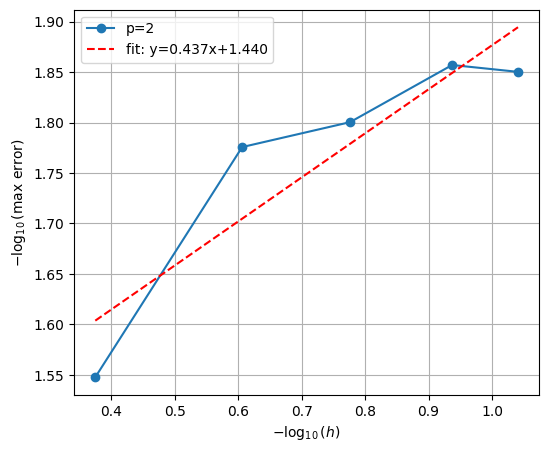

In [158]:
key = 100
np.random.seed(key)

NN = [15, 30, 65, 100,145]
KK = [30, 40, 40, 55, 65]

RR = [1e-12,1e-12,1e-13,1e-13,1e-13]
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    overlap = 0.2
    # generate points
    X_inner, X_boundary, C, R ,_ = generator_points_2d_overlap(
    N_patch_grid, N_local_per_patch, N_boundary, overlap, False)

    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 2
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    K = KK[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    if order == 0:
        UY,LBDF1,LBDF2,LI = rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg)
    else:
        UY,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)
    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 19
removed patches: 6
patch nX min/mean/max: 4 / 17.58 / 38
X_inner: 128
X_boundary: 15
cover X_inner min/mean/max: 1 2.61 4 uncovered: 0
cover X_all min/mean/max: 1 2.55 4 uncovered: 0
X.shape 143


cond(LI) = 1.000000573423332
cond(LBDF1) = 723478904574.8105
cond(LBDF2) = 1446957798942.3997
h = 4.219e-01, L2 error = 1.124e-02, 
Run Q=2, N_local_per_patch=30
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 20
removed patches: 5
patch nX min/mean/max: 2 / 33.85 / 75
X_inner: 263
X_boundary: 30
cover X_inner min/mean/max: 1 2.57 4 uncovered: 0
cover X_all min/mean/max: 1 2.54 4 uncovered: 0
X.shape 293
cond(LI) = 1.0000000943699612
cond(LBDF1) = 2078985340045.8665
cond(LBDF2) = 4157970642788.32
h = 2.476e-01, L2 error = 1.029e-02, 
Run Q=3, N_local_per_patch=65
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 20
removed patches: 5
patch nX min/mean/max: 4 / 71.40 / 161
X_inner: 567
X_boundary: 65
cover X_inner min/mean/max: 1 2.52 4 uncovered: 0
cover X_all min/mean/max: 1 2.48 4 uncovered: 0
X.shape 632
cond(LI) = 1.0000001511999868
cond(LBDF1) = 20805057669847.125
cond(LBDF2) = 41610114875653.53


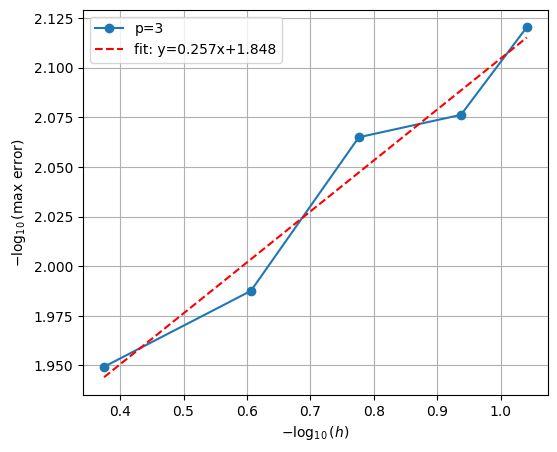

In [159]:
key = 100
np.random.seed(key)

NN = [15, 30, 65, 100,145]
KK = [20, 30, 45, 55, 65]
RR = [1e-12,1e-13,1e-13,1e-15,1e-14]
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    overlap = 0.2
    # generate points
    X_inner, X_boundary, C, R ,_ = generator_points_2d_overlap(
    N_patch_grid, N_local_per_patch, N_boundary, overlap, False)

    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 3
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    K = KK[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    if order == 0:
        UY,LBDF1,LBDF2,LI = rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg)
    else:
        UY,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)
    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 19
removed patches: 6
patch nX min/mean/max: 4 / 17.58 / 38
X_inner: 128
X_boundary: 15
cover X_inner min/mean/max: 1 2.61 4 uncovered: 0
cover X_all min/mean/max: 1 2.55 4 uncovered: 0
X.shape 143
cond(LI) = 1.0000001530299347
cond(LBDF1) = 1010259045981.8036
cond(LBDF2) = 2020514180583.6008
h = 4.219e-01, L2 error = 1.446e-02, 
Run Q=2, N_local_per_patch=30
Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 20
removed patches: 5
patch nX min/mean/max: 2 / 33.85 / 75
X_inner: 263
X_boundary: 30
cover X_inner min/mean/max: 1 2.57 4 uncovered: 0
cover X_all min/mean/max: 1 2.54 4 uncovered: 0
X.shape 293
cond(LI) = 1.0000007851434083
cond(LBDF1) = 17270781305613.68
cond(LBDF2) = 34541559441195.95
h = 2.476e-01, L2 error = 7.684e-03, 
Run Q=3, N_local_per_patch=65
Generator's raw C: 25
Generator's R = 0.7244402670709812
origina

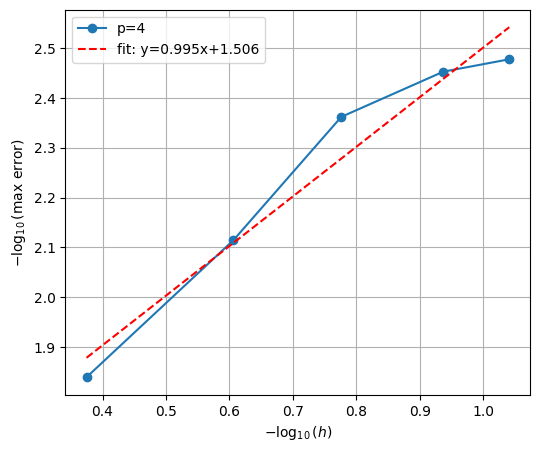

In [172]:
key = 100
np.random.seed(key)

NN = [15, 30, 65, 100, 145]
KK = [30, 30, 60, 85,  130]
RR = [1e-13,1e-12,1e-12,1e-12,1e-13]
for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    overlap = 0.2
    # generate points
    X_inner, X_boundary, C, R ,_ = generator_points_2d_overlap(
    N_patch_grid, N_local_per_patch, N_boundary, overlap, False)
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 4
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    K = KK[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    if order == 0:
        UY,LBDF1,LBDF2,LI = rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg)
    else:
        UY,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)
    error = np.max(np.abs(UY - u_true))
    e = np.linalg.norm(UY - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    # 绘图并画出拟合直线
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


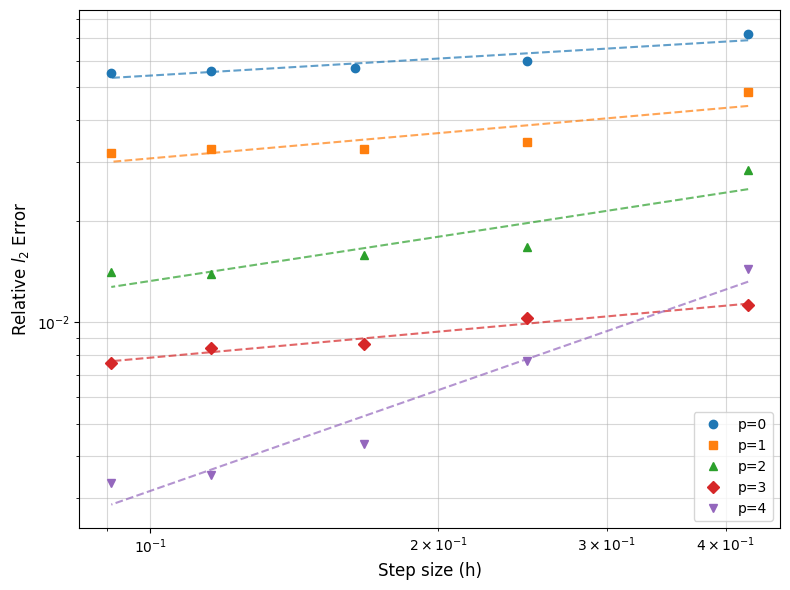

In [173]:
markers = ['o', 's', '^', 'D', 'v']  
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
labels = ['p=0', 'p=1', 'p=2', 'p=3','p=4']
plt.figure(figsize=(8, 6))

for i in range(5):
    h = H[i, :]
    e = E[i, :]
    log_h = np.log(h)
    log_e = np.log(e)
    slope, intercept = np.polyfit(log_h, log_e, 1)
    fit_e = np.exp(intercept) * h**slope
    # plt.loglog(h, e, markers[i], color=colors[i], label=f'{labels[i]} (Slope: {slope:.2f})')
    plt.loglog(h, e, markers[i], color=colors[i], label=f'{labels[i]}')

    plt.loglog(h, fit_e, linestyle='--', color=colors[i], alpha=0.7)

plt.xlabel('Step size (h)', fontsize=12)
plt.ylabel('Relative $l_2$ Error', fontsize=12)
# plt.title('Convergence Study: Least Squares Fit', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.tight_layout()
# plt.savefig('./result/heat_rfmfd_p=0123_convergence_scatter.eps', bbox_inches='tight')
plt.show()

$Operator learning$

In [36]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import spsolve
from scipy.linalg import cholesky, solve_triangular
import time

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 0
    def to_numpy(u):
        if sp.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)

def wls_chol_rowmax(A, b, reg=0.0):
    """
    WLS_CHOL_ROWMAX
    Solve weighted least squares using Cholesky factorization
        min_x || W (A x - b) ||_2^2
    where weights w_i = 1 / (max_j |A_ij| + eps)
    Parameters
    ----------
    A : scipy.sparse matrix, shape (M, N)
        Sparse system matrix
    b : ndarray, shape (M,)
        Right-hand side
    reg : float, optional
        Tikhonov regularization parameter (default 0)
    Returns
    -------
    x : ndarray, shape (N,)
        Solution vector
    info : dict
        Diagnostic information
    """
    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")
    A = A.tocsr()

    b = np.asarray(b,dtype=np.float64).squeeze(-1) 
    M, N = A.shape
    assert b.shape[0] == M, "Dimension mismatch"
    # -------------------------------------------------
    # Step 1: row-wise max for sparse matrix
    # -------------------------------------------------
    # Equivalent to MATLAB: full(max(abs(A), [], 2))
    # row_max = np.asarray(np.abs(A).max(axis=1)).ravel()   # (M,) ndarray
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    eps0 = 1e-12
    w = 10 / (row_max + eps0)   # (M,)
    # -------------------------------------------------
    # Step 2: apply weights implicitly
    # -------------------------------------------------
    # Aw = W * A, bw = W * b
    W = sp.diags(w, offsets=0, format='csr')
    Aw = W @ A
    bw = w * b
  
    # -------------------------------------------------
    # Step 3: normal equations
    # -------------------------------------------------
    AtA = Aw.T @ Aw    # (N, N), sparse SPD (hopefully)
    Atb = Aw.T @ bw

    if reg > 0:
        AtA = AtA + reg * sp.eye(N, format='csr')

    # -------------------------------------------------
    # Step 4: Cholesky solve
    # -------------------------------------------------
    try:
        # scipy 对稀疏 Cholesky 没有内建 chol
        # spsolve 等价于 MATLAB 的 "\" 退化路径
        x = spla.spsolve(AtA, Atb)
        flag = 0
    except Exception:
        print("Warning: linear solve failed.")
        x = spla.lsmr(AtA, Atb)[0]
        flag = 1
    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    try:
        cond_est = spla.onenormest(AtA) * spla.onenormest(spla.inv(AtA))
    except Exception:
        cond_est = np.nan

    info = {
        "flag": flag,
        "row_max_min": row_max.min(),
        "row_max_max": row_max.max(),
        "cond_est": cond_est
    }
    return x, info

def rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order):
    """
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    f_func, g_func: Python callable returning torch tensor
    K: number of neighbors
    order: polynomial order (1,2,3,...)
    """
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]

    tree = cKDTree(X)
    dist, idx = tree.query(Y, k=K, workers=-1)  # (M,K)

    # Construct sparse L matrix
    LBDF2 = lil_matrix((M, N)) # 按行/按元素赋值效率高
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))

    # Construct RHS
    RHS = np.zeros((M,1))
    f_val = f_func(Yin[:,0:1], Yin[:,1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:,0:1], Yb[:,1:2], t) if callable(g_func) else g_func
    u0 = u0_func(Y[:,0:1], Y[:,1:2]) if callable(u0_func) else u0_func[:, None]

    O = np.zeros((Norder,Norder))

    start = time.time()
    for i in range(M):
        RHS_lap = np.zeros((K+Norder,1))
        RHS_ide = np.ones((K+Norder,1))
        AP = np.zeros((K+Norder,K+Norder))
        P = np.ones((K,Norder))
        y = Y[i,:] # (2,)
        idx_local = idx[i,:]    # (K,)
        Z = X[idx_local]       # (K,2)
        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (K,K)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (K,K)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        # print(np.max(np.max(Phi_jj)), np.min(np.min(Phi_jj)))
        phi_xj, lap_phi, _  = laplacian_phi_wrt_y(Phi, y, Z, eps=1e-8) # (K,1)
        ## AP
        P = poly2D(Z, order)  # (K,Norder)
        AP[:K,:] = np.concatenate([Phi_jj,P], axis = 1) # (K,K+3)
        AP[K:,:-Norder] = P.T # (Norder,K)
        AP = AP + reg * np.eye(K+Norder)
        LU = lu_factor(AP)
        ## w_ide, w_lap
        p_y = poly2D_at_point(y, order)  # (Norder,1)
        RHS_ide[:K,0] = phi_xj[:,0]                           # shape (K,)
        RHS_ide[K:,0] = p_y[:,0]
        w_ide = lu_solve(LU, RHS_ide).T # (1,K+Norder)
        # w_ide = np.linalg.solve(AP,RHS_ide).T # (1,K+Norder)
        RHS_lap[:K,0] = lap_phi[:,0]
        RHS_lap[K:,0] = laplacian_poly2D(order, y)[:,0]
        w_lap = lu_solve(LU, RHS_lap).T # (1,K+Noder)
        # w_lap = np.linalg.solve(AP,RHS_lap).T # (1,K+Noder)
        if i < M1 :
            LBDF1[i:i+1,idx_local] += (w_ide[0:1,:K] - tau * w_lap[0:1,:K])
            LBDF2[i:i+1,idx_local] += (3 * w_ide[0:1,:K] - 2* tau * w_lap[0:1,:K])
        else:
            LBDF1[i:i+1,idx_local] += w_ide[0:1,:K]
            LBDF2[i:i+1,idx_local] += w_ide[0:1,:K]
        LI[i:i+1,idx_local] += w_ide[0:1,:K]
        
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    end = time.time()
    print("Compile derivative matrix time =", end - start, "seconds")
       
    U = np.zeros((M, NT))
    U[:,0:1] = u0   # (N,1)
    U[M1:,:] = g_val

    LI = LI.tocsr() # 高效矩阵乘法、解线性系统
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()

    if M == N:
        # BDF1
        alpha_0 = spsolve(LI,u0)[:,None]
        right1 = LI @ alpha_0             # (M,1)
        rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
        alpha_1 = spsolve(LBDF1,RHS)[:,None]
        U[:M1,1:2] = LI[:M1, :] @ alpha_1
        U[M1:,1:2]  = g_val[:,1:2]
        # BDF2
        LU = splu(LBDF2.tocsc())
        for i in range(1,NT-1):  # NT-2
            right1 = LI @ (4 * alpha_1 - alpha_0)
            rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
            RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
            alpha_2 = LU.solve(RHS)
            U[:M1,i+1:i+2] = LI[:M1, :] @ alpha_2
            U[M1:,i+1:i+2] = g_val[:,i+1:i+2]
            alpha_0 = alpha_1
            alpha_1 = alpha_2
    else:
        print("M is not equal to N. Please use QR.")
        # ===========================================================
        # M != N : BDF2 + row-max weighted least squares (Cholesky)
        # ===========================================================
        # ---------- BDF1 start ----------
        # alpha_0 已由初值隐式给定：LI * alpha_0 = u0
        reg1 = reg
        alpha_0, info = wls_chol_rowmax(LI, u0, reg)
        print("LI's condition numbers is ", np.sqrt(info["cond_est"]))
        alpha_0 = alpha_0.reshape(-1, 1)
        # print(alpha_0.shape)
        
        rhs_int = LI[:M1, :] @ alpha_0 + tau * f_val[:, 1:2]
        RHS = np.vstack([rhs_int, g_val[:, 1:2]])

        alpha_1, _ = wls_chol_rowmax(LBDF1, RHS, reg)
        alpha_1 = alpha_1.reshape(-1, 1)

        U[:M1, 1:2] = LI[:M1, :] @ alpha_1
        U[M1:, 1:2] = g_val[:, 1:2]

        # ---------- fixed row weights from LBDF2 ----------
        row_max = np.abs(LBDF2).max(axis=1).toarray().ravel()
        row_max[row_max == 0.0] = 1.0
        w = 10 / ((row_max + 1e-12) ** 2) # reg = 1e-12
        W = sp.diags(w, offsets=0, shape=(M, M), format="csr")

        # ---------- normal matrix and Cholesky ----------
        AtWA = LBDF2.T @ (W @ LBDF2)
        cond_AtWA_est = spla.onenormest(AtWA) * spla.onenormest(spla.inv(AtWA))
        print("LBDF2's condition numbers is ", np.sqrt(cond_AtWA_est))
        if reg1 > 0:
            AtWA = AtWA + reg1 * sp.eye(N, format="csr")

        # dense Cholesky
        R = cholesky(AtWA.toarray(), lower=False)
        # ---------- BDF2 time stepping ----------
        for i in range(1, NT - 1):
            rhs_int = LI[:M1, :] @ (4 * alpha_1 - alpha_0) \
                      + 2 * tau * f_val[:, i+1:i+2]

            RHS = np.vstack([rhs_int, g_val[:, i+1:i+2]])
            AtWb = LBDF2.T @ (W @ RHS)

            # solve (R^T R) alpha = AtWb
            y = solve_triangular(R.T, AtWb, lower=True)
            alpha_2 = solve_triangular(R, y, lower=False)

            U[:M1, i+1:i+2] = LI[:M1, :] @ alpha_2
            U[M1:, i+1:i+2] = g_val[:, i+1:i+2]

            alpha_0 = alpha_1
            alpha_1 = alpha_2


    return U,LBDF1,LBDF2,LI


#还得改成每次求解多个方程的情况


class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(0.9225)**2 * x**2) # operator
        output = self.input_layer(x)
        output = torch.sin(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.uniform_(m.bias, -0, 0)

Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 20
removed patches: 5
patch nX min/mean/max: 5 / 108.65 / 246
X_inner: 871
X_boundary: 200
cover X_inner min/mean/max: 1 2.49 4 uncovered: 0
cover X_all min/mean/max: 1 2.44 4 uncovered: 0
X.shape: 1071
Compile derivative matrix time = 7.62577748298645 seconds
M is not equal to N. Please use QR.
LI's condition numbers is  3022.095262338406
LBDF2's condition numbers is  3218.3010506951214
p = 3; L infity error in u_rfmfd: 8.362e-02
p = 3; Relative L2 error in u_rfmfd: 5.677e-03
p = 3; Relative L2 error at T time of u_rfmfd: 2.106e-03
Time step 0, Relative L2 error: 8.813e-18
Time step 1, Relative L2 error: 7.235e-03
Time step 2, Relative L2 error: 8.264e-03
Time step 3, Relative L2 error: 9.300e-03
Time step 4, Relative L2 error: 1.014e-02
Time step 5, Relative L2 error: 1.078e-02
Time step 6, Relative L2 error: 1.128e-02
Time step 7, Relative L2 error: 1.164e-02
Time step 8, Relative L2 error: 1

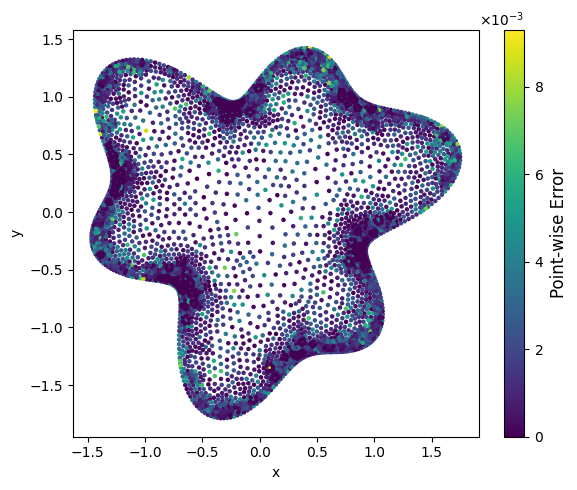

In [40]:
import matplotlib.ticker as ticker

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 

# u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
f_func = lambda x, y, t: np.sin(x) * np.cos(y) * np.exp(-t)
g_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
# u0_func = lambda x, y : 1 + np.sin(x) * np.cos(y)


tau = 1e-3
T = 2e-1

Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

# data = loadmat('./data/mydata_heat_pdetool_4029_T2e-2_tau1e-4.mat') # order = 3; K = 150

data = loadmat('../data/mydata_heat_pdetool_4029_T2e-1_tau1e-3.mat') # order = 3; K = 150


#'u0_0', 'uT_0', 'U0_new',  'UT_new', 'p','in','bc'
# (M,1), (M,NT),  (M,100), (100,M,NT)
p,u0_0,uT_0, U0_new, UT_new, index_in,index_bc = data['p'],data['u0_0'],data['uT_0'],data['U0_new'],data['UT_new'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print("UT_new.shape,", UT_new.shape) # (n_batch,M,NT)

torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2

U0_new = np.concatenate([U0_new[index_in,:],U0_new[index_bc,:]],axis=0)
testnum = 0
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
u0_func = U0_new[:,testnum]  # (M,)

order = 3
K = 100

reg = 1e-12
u_true = UT_new[testnum,:,:]
# print(u_true.shape) # (M,NT)
u_true = np.concatenate([u_true[index_in,:],u_true[index_bc,:]],axis=0)
# print(u_true.shape) # print(u_true.shape) # (M,NT)

# #===========================================================
# #==================== Source points X ====================
# #===========================================================

# N_patch_grid = 5
# N_local_per_patch = 200
# N_boundary = 200

N_patch_grid = 5
N_local_per_patch = 100
N_boundary = 200
overlap = 0.2

# generate points
X_inner, X_boundary, C, R, _ = generator_points_2d_overlap(N_patch_grid, N_local_per_patch, N_boundary, overlap, False)
X = np.vstack([X_inner, X_boundary])
print(f"X.shape: {X.shape[0]}" )
# # ===========================================================

if order == 0:
    UY,LBDF1,LBDF2,LI = rfm_fd_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg)
else:
    U,LBDF1,LBDF2,LI = rfm_fd_poly_solve_heat(X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, K, reg, order)

# print("U.shape ",U.shape) #(M,NT)
error = np.abs(U- u_true)
error = np.max(np.max(error))

print(f'p = {order}; L infity error in u_rfmfd: {error:.3e}')
error_u = relative_l2(U.ravel(), u_true.ravel())
print(f'p = {order}; Relative L2 error in u_rfmfd: {error_u:.3e}')

error_u = relative_l2(U[:,-1:], u_true[:,-1:])
print(f'p = {order}; Relative L2 error at T time of u_rfmfd: {error_u:.3e}')

e = np.abs(U[:,-1].ravel() - u_true[:,-1].ravel())
e =np.asarray(e)

for i in range(Nt):
    err_time = relative_l2(U[:,i], u_true[:,i])
    print(f'Time step {i}, Relative L2 error: {err_time:.3e}')

plt.figure(figsize=(6,5))
print(Y[:,0].shape, Y[:,1].shape, e.shape)
sc = plt.scatter(Y[:,0], Y[:,1], c = e, cmap='viridis', s=5)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/p={order}_error_200_size{M}.eps', bbox_inches='tight')
plt.show()



In [15]:
def build_wls_solver(A, reg=1e-12):
    """
    Precompute WLS system for repeated RHS solves.
    """

    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")

    A = A.tocsr()
    M, N = A.shape

    # -------------------------------------------------
    # weight (computed ONCE)
    # -------------------------------------------------
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    w = 10.0 / (row_max + 1e-12)

    W = sp.diags(w, format='csr')

    # -------------------------------------------------
    # precompute matrices
    # -------------------------------------------------
    Aw = W @ A
    AtA = Aw.T @ Aw + reg * sp.eye(N, format='csr')

    # factorization (FAST SOLVE)
    solver = spla.factorized(AtA.tocsc())

    # -------------------------------------------------
    # return closure
    # -------------------------------------------------
    def solve(RHS):
        """
        RHS: (M,K)
        """
        RHS = np.asarray(RHS, dtype=np.float64)

        if RHS.ndim == 1:
            RHS = RHS[:, None]

        # weighted RHS
        RHSw = w[:, None] * RHS

        Atb = Aw.T @ RHSw
        x = solver(Atb)

        if x.ndim == 1:
            x = x[:, None]

        return x

    return solve

def test_solver(LBDF1, LBDF2, LI,
                f_func, g_func, u0_func,
                Yin, Yb, t, tau,
                scheme="BDF2"):
    """
    Multi-batch heat solver using unified WLS (row-max weighted least squares).

    Returns
    -------
    U : ndarray, shape (n_batch, M, NT)
    """

    # --------------------------------------------------
    # geometry
    # --------------------------------------------------
    Y = np.concatenate([Yin, Yb], axis=0)
    M = Y.shape[0]
    M2 = Yb.shape[0]
    M1 = M - M2
    NT = t.shape[0]

    # --------------------------------------------------
    # data
    # --------------------------------------------------
    f_val = f_func(Yin[:, 0:1], Yin[:, 1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:, 0:1], Yb[:, 1:2], t) if callable(g_func) else g_func

    u0 = u0_func(Y[:, 0:1], Y[:, 1:2]) if callable(u0_func) else u0_func
    u0 = np.asarray(u0, dtype=np.float64)

    # --------------------------------------------------
    # batch handling
    # --------------------------------------------------
    if u0.ndim == 1:
        u0 = u0[:, None]

    n_batch = u0.shape[1]

    solve_LBDF1 = build_wls_solver(LBDF1, reg=1e-12)
    solve_LBDF2 = build_wls_solver(LBDF2, reg=1e-12)
    solve_LI    = build_wls_solver(LI, reg=1e-12)

    # --------------------------------------------------
    # initial solve (LI)
    # --------------------------------------------------
    alpha_0 = solve_LI(u0)

    # --------------------------------------------------
    # storage
    # --------------------------------------------------
    U = np.zeros((n_batch, M, NT), dtype=np.float64)
    U[:, :, 0] = u0.T
    U[:, M1:, :] = g_val[None, :, :]

    reg = 1e-12

    # ==================================================
    # BDF1
    # ==================================================
    if scheme == "BDF1":

        for i in range(0, NT - 1):

            rhs_int = LI @ alpha_0
            if rhs_int.ndim == 1:
                rhs_int = rhs_int[:, None]

            rhs = rhs_int[:M1, :] + tau * f_val[:, i + 1:i + 2]

            RHS = np.vstack([
                rhs,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_1 = solve_LBDF1(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_1).T

            alpha_0 = alpha_1

        return U
    # ==================================================
    # BDF2
    # ==================================================
    elif scheme == "BDF2":

        # -----------------------------
        # step 1: initial BDF1 step
        # -----------------------------
        rhs_int = LI[:M1, :] @ alpha_0 + tau * f_val[:, 1:2]

        RHS = np.vstack([
            rhs_int,
            np.repeat(g_val[:, 1:2], n_batch, axis=1)
        ])

        alpha_1 = solve_LBDF1(RHS)

        U[:, :M1, 1] = (LI[:M1, :] @ alpha_1).T

        # -----------------------------
        # BDF2 time loop
        # -----------------------------
        for i in range(1, NT - 1):

            rhs_int = (
                LI[:M1, :] @ (4 * alpha_1 - alpha_0)
                + 2 * tau * f_val[:, i + 1:i + 2]
            )

            RHS = np.vstack([
                rhs_int,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_2 = solve_LBDF2(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_2).T
            U[:, M1:, i + 1] = g_val[:, i + 1]

            alpha_0 = alpha_1
            alpha_1 = alpha_2

        return U

    else:
        raise ValueError("Unsupported scheme. Use 'BDF1' or 'BDF2'.")

UT_new.shape  (100, 4029, 201)
After reordering, U0_new.shape  (4029, 100)
p = 3, inference time: 16.2203 秒
error_L2.shape: (100, 1), error_inf.shape: (100, 4029, 201)
p = 3, test on 100 samples. The mean of max error: 8.707997e-02, and mean of relative L2 error: 6.335124e-03
p = 3, test on 100 samples. The variance of max error: 1.623823e-04, and variance of relative L2 error: 1.111433e-06


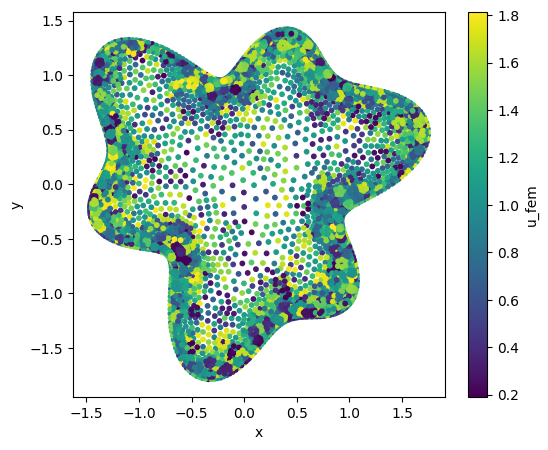

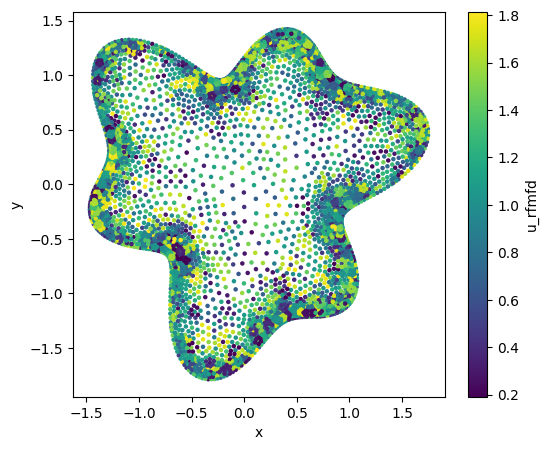

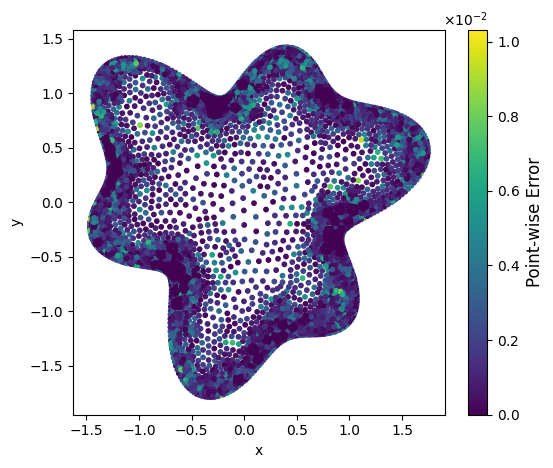

In [41]:
import time

E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points


u_true = UT_new # (100,M,NT)
print( "UT_new.shape ", u_true.shape) 
u_true = np.concatenate([u_true[:,index_in,:],u_true[:,index_bc,:]], axis=1)

print("After reordering, U0_new.shape ", U0_new.shape) #(M,100)


start_time = time.time()
UY = test_solver(LBDF1, LBDF2, LI,
                f_func, g_func, U0_new,
                Yin, Yb, t, tau,
                scheme="BDF2") 
# UY =  np.transpose(UY, (2, 0, 1)) # (n_batch, M, NT)
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")


error_inf = np.abs(UY - u_true) # (n_batch, M, NT)
E_inf =  np.max(np.max(error_inf, axis=2), axis=1) # (n_batch, 1)
error_L2 = (np.linalg.norm(UY - u_true, axis=(1,2)) / np.linalg.norm(u_true, axis=(1,2)))[:, None] # (n_batch, 1)
print(f"error_L2.shape: {error_L2.shape}, error_inf.shape: {error_inf.shape}") #(n_batch,1), (n_batch,M,NT)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")

np.random.seed(30)
q = np.random.randint(0, 100)
u_true_q = u_true[q,:,-1]
UY_q = UY[q,:,-1]
error_inf_q = error_inf[q,:,-1]


plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = u_true_q, cmap='viridis', s=10)
plt.colorbar(label='u_fem')
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/heat_rfmfd_p={order}_u_fem_one_test_sample.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y[:,0], Y[:,1], c = UY_q, cmap='viridis', s=5)
plt.colorbar(label='u_rfmfd')
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/heat_rfmfd_p={order}_UY_one_test_sample.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
sc =  plt.scatter(Y[:,0], Y[:,1], c = error_inf_q, cmap='viridis', s=10)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig(f'./result/heat_rfmfd_p={order}_error_one_test_sample.eps', bbox_inches='tight')
plt.show()



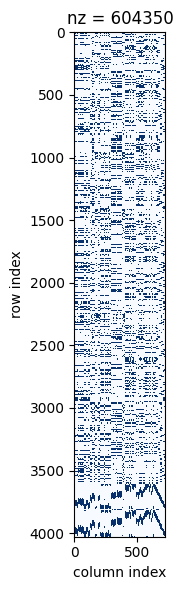

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

def spy_like_matlab(A):
    import copy
    if sp.issparse(A):
        A = A.tocsr()
        M, N = A.shape
        img = np.zeros((M, N), dtype=np.uint8)
        img[A.nonzero()] = 1
    else:
        img = (A != 0).astype(np.uint8)

    my_cmap = copy.copy(plt.cm.Blues) # or plt.cm.plasma
    my_cmap.set_bad(color='white')
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=my_cmap, origin='upper', interpolation='nearest')
    plt.xlabel('column index')
    plt.ylabel('row index')
    plt.title(f'nz = {img.sum()}')
    plt.tight_layout()
    # plt.savefig('L.eps', bbox_inches='tight')
    plt.show()
spy_like_matlab(LBDF2)

In [15]:
for name, param in Phi.named_parameters():
    print(name, param.data)

input_layer.weight tensor([[ 0.2842],
        [-0.2967],
        [-0.1604],
        [-0.2334],
        [-0.5244],
        [-0.0046],
        [-0.2725],
        [ 0.2287],
        [-0.2161],
        [-0.0757],
        [-0.0685],
        [ 0.0640],
        [ 0.3066],
        [ 0.3625],
        [-0.0834],
        [ 0.0658],
        [ 0.3209],
        [-0.0518],
        [-0.1160],
        [-0.0907],
        [ 0.1197],
        [ 0.0820],
        [-0.0369],
        [ 0.0720],
        [ 0.0468],
        [-0.0157],
        [-0.4444],
        [ 0.1845],
        [-0.0036],
        [ 0.0795],
        [-0.2547],
        [ 0.3697],
        [-0.0387],
        [-0.0531],
        [ 0.0157],
        [-0.1510],
        [ 0.3340],
        [-0.0718],
        [ 0.1586],
        [-0.2193],
        [ 0.1426],
        [-0.0696],
        [ 0.3045],
        [ 0.1889],
        [-0.2389],
        [ 0.2154],
        [-0.2263],
        [-0.0997],
        [ 0.0391],
        [-0.2642]], device='cuda:1', dtype=torch.f